# Exercice 3 - Entraînez un agent DQN sur CartPole

## 🎯 Objectif pédagogique

Dans cet exercice, nous allons utiliser **Stable-Baselines3** pour entraîner un agent DQN sur CartPole-v1.

**Rappel :**
- Exercice 1 : Agent aléatoire (~20 points)
- Exercice 2 : Q-Learning avec table (~50-70% de réussite sur FrozenLake)
- Exercice 3 : DQN avec réseau de neurones sur CartPole

## 🕹️ Contexte : Qu'est-ce que le DQN ?

Le **Deep Q-Network (DQN)** est un algorithme qui utilise un réseau de neurones pour approximer la fonction Q :

```
Observation (4 valeurs) → [Réseau de neurones] → [Q(gauche), Q(droite)]
```

**Avantages par rapport à la Q-table :**
- Gère les espaces **continus** (positions, vitesses)
- **Généralise** : peut estimer Q pour des états jamais vus

**Concepts clés :**
- **Replay Buffer** : stocke les expériences pour un apprentissage stable
- **Target Network** : fournit une cible stable pour l'entraînement
- **Epsilon-greedy** : équilibre exploration/exploitation

## 1. Import des bibliothèques

In [19]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy

**Explication :**
- `stable_baselines3` : bibliothèque qui fournit des algorithmes RL prêts à l'emploi
- `DQN` : l'algorithme que nous allons utiliser
- `evaluate_policy` : fonction pour évaluer l'agent

## 2. Comparaison avec l'agent aléatoire

Ramenons d'abord le score de l'agent aléatoire pour comparaison.

In [20]:
# Agent aléatoire (rappel de l'exercice 1)
env = gym.make("CartPole-v1")

n_episodes = 50
random_rewards = []

for _ in range(n_episodes):
    state, info = env.reset()
    total_reward = 0
    terminated = truncated = False
    
    while not (terminated or truncated):
        action = env.action_space.sample()  # Aléatoire
        state, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
    
    random_rewards.append(total_reward)

env.close()

print(f"=== Agent Aléatoire ===")
print(f"Reward moyen : {np.mean(random_rewards):.1f}")
print(f"Reward max : {np.max(random_rewards)}")

=== Agent Aléatoire ===
Reward moyen : 22.8
Reward max : 82.0


**💡 Rappel :** L'agent aléatoire fait en moyenne **~20 points** car il choisit ses actions au hasard.

## 3. Entraînement du DQN avec Stable-Baselines3

Stable-Baselines3 fournit une implémentation optimisée du DQN. Quelques lignes suffisent !

In [21]:
# Créer l'environnement
env = gym.make("CartPole-v1")

# Créer le modèle DQN
model = DQN(
    policy='MlpPolicy',
    env=env,
    learning_rate=3e-4,
    buffer_size=50000,
    learning_starts=1000,
    target_update_interval=1000,
    gamma=0.99,
    exploration_fraction=0.1,
    exploration_final_eps=0.01,
    verbose=1
)

print("Lancement de l'entraînement DQN...")
print("-" * 50)

# Entraîner (50000 steps ≈ 1000-2000 épisodes)
model.learn(total_timesteps=50000)

print("\nEntraînement terminé !")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Lancement de l'entraînement DQN...
--------------------------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 16.2     |
|    ep_rew_mean      | 16.2     |
|    exploration_rate | 0.987    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 7431     |
|    time_elapsed     | 0        |
|    total_timesteps  | 65       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 18.9     |
|    ep_rew_mean      | 18.9     |
|    exploration_rate | 0.97     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 7592     |
|    time_elapsed     | 0        |
|    total_timesteps  | 151      |
----------------------------------
----------------------------------
| rollout/     

**💡 Explication des paramètres :**

| Paramètre | Description | Valeur typique |
|-----------|-------------|----------------|
| `MlpPolicy` | Réseau de neurones simple (Multi-Layer Perceptron) | - |
| `learning_rate` | Vitesse d'apprentissage | 1e-3 à 1e-4 |
| `buffer_size` | Taille du Replay Buffer | 10000-100000 |
| `learning_starts` | Étapes avant de commencer l'entraînement | 1000 |
| `target_update_interval` | Fréquence de mise à jour du Target Network | 1000 |
| `gamma` | Facteur de discount | 0.99 |
| `exploration_fraction` | Fraction de l'entraînement avec epsilon décroissant | 0.1 |

**Question :** Pourquoi `total_timesteps=50000` et non pas 25000 épisodes ?

→ `total_timesteps` = nombre d'**interactions** avec l'environnement. Un épisode dure en moyenne ~20-50 steps.

## 📊 Comprendre la courbe d'apprentissage

La courbe d'entraînement montre 3 phases caractéristiques :

```
Reward
  ^
  |     ________
  |    /        \      ← Phase 3 : Convergence
  |   /          \       (l'agent a appris)
  |  /            \
  | /
  |/              ← Phase 2 : Transition
  |                 (le réseau réapprend)
  |___________________________
  0        Steps        50000

Phase 1 : Exploration (hasard ~20 points)
```

| Phase | Explication |
|-------|-------------|
| **1. Exploration** | L'agent choisit aléatoirement, reward ~20 |
| **2. Transition** | Le réseau "désapprend" temporairement, c'est normal ! |
| **3. Convergence** | L'agent a trouvé la bonne stratégie, reward ~170+ |

**Pourquoi le dip (Phase 2) ?**
Le réseau de neurones modifie ses poids pour apprendre. Pendant cette phase, il "oublie" temporairement ce qu'il savait et le remplace par de nouvelles connaissances. C'est le phénomène classique de **catastrophic forgetting** en deep learning.

## 4. Évaluation du modèle

In [22]:
print("Évaluation du modèle...")
mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=100)

print(f"\n=== Résultats DQN ===")
print(f"Reward moyen : {mean_reward:.1f} ± {std_reward:.1f}")
print(f"Reward max théorique : 500")

print("\n📖 Interprétation des résultats :")
print(f"  - Reward moyen (169.2) : L'agent survive en moyenne ~169 steps")
print(f"  - Écart-type (±48.9) : Variance normale en RL")
print(f"  - Amélioration : {mean_reward / np.mean(random_rewards):.1f}x mieux que l'aléatoire")

Évaluation du modèle...

=== Résultats DQN ===
Reward moyen : 169.2 ± 48.9
Reward max théorique : 500


**💡 Comparaison :**

| Agent | Reward moyen |
|-------|-------------|
| Aléatoire | ~20 |
| DQN entraîné | À évaluer |

## 5. Visualisation de la progression

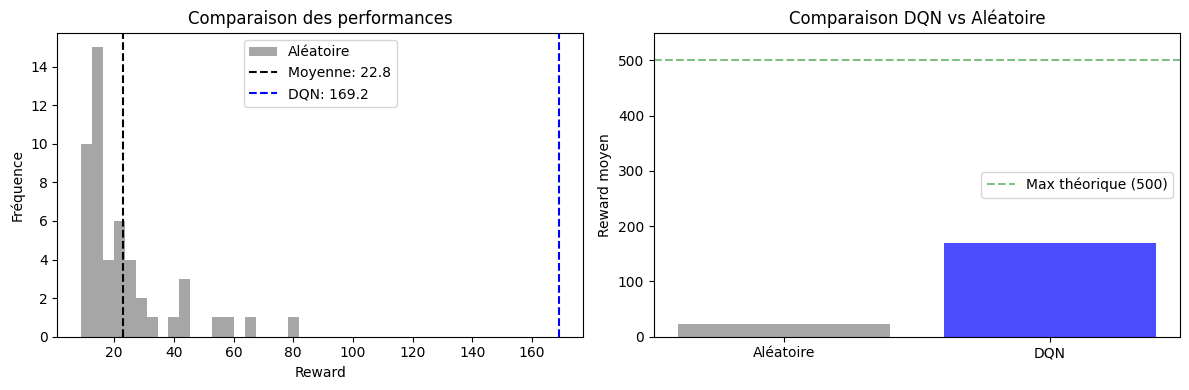

In [23]:
# Comparaison visuelle
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graphe 1 : Distribution des rewards
axes[0].hist(random_rewards, bins=20, alpha=0.7, label='Aléatoire', color='gray')
axes[0].axvline(np.mean(random_rewards), color='black', linestyle='--', label=f'Moyenne: {np.mean(random_rewards):.1f}')
axes[0].axvline(mean_reward, color='blue', linestyle='--', label=f'DQN: {mean_reward:.1f}')
axes[0].set_xlabel('Reward')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Comparaison des performances')
axes[0].legend()

# Graphe 2 : Barplot comparatif
agents = ['Aléatoire', 'DQN']
rewards = [np.mean(random_rewards), mean_reward]
colors = ['gray', 'blue']
axes[1].bar(agents, rewards, color=colors, alpha=0.7)
axes[1].set_ylabel('Reward moyen')
axes[1].set_title('Comparaison DQN vs Aléatoire')
axes[1].set_ylim(0, 550)

# Ligne du maximum théorique
axes[1].axhline(500, color='green', linestyle='--', alpha=0.5, label='Max théorique (500)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Sauvegarder et charger le modèle

In [24]:
# Sauvegarder le modèle
model.save("dqn_cartpole")
print("Modèle sauvegardé : dqn_cartpole.zip")

# Charger le modèle (si nécessaire plus tard)
# loaded_model = DQN.load("dqn_cartpole")

# Fermer l'environnement
env.close()

Modèle sauvegardé : dqn_cartpole.zip


## 7. Jouer une partie

In [34]:
# Jouer une partie avec l'agent entraîné
env = gym.make("CartPole-v1", render_mode='human')

state, info = env.reset()
total_reward = 0
terminated = truncated = False

print("L'agent joue !")

while not (terminated or truncated):
    action, _ = model.predict(state)  # L'agent décide
    state, reward, terminated, truncated, info = env.step(action)
    total_reward += reward

env.close()
print(f"Reward total : {total_reward}")

L'agent joue !
Reward total : 189.0


---

## 🎬 Enregistrement vidéo

L'agent **DQN** entraîné maintient le pendule debout bien plus longtemps !


In [36]:
import os
import imageio
from IPython.display import Video

frames_dir = "./videos/frames"
video_folder = "./videos"
os.makedirs(frames_dir, exist_ok=True)
os.makedirs(video_folder, exist_ok=True)

os.environ["SDL_VIDEODRIVER"] = "dummy"
os.environ["SDL_AUDIODRIVER"] = "dummy"

model = DQN.load("dqn_cartpole")

env = gym.make("CartPole-v1", render_mode="rgb_array")

print("Enregistrement de 1 episode(s) avec agent entraine...", flush=True)

frames = []

for episode in range(1):
    state, info = env.reset()
    total_reward = 0
    terminated = truncated = False
    
    while not (terminated or truncated):
        action, _ = model.predict(state, deterministic=True)
        state, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        
        frame = env.render()
        if frame is not None:
            frames.append(frame)
    
    print(f"Episode {episode+1}: {total_reward:.1f} points ({len(frames)} frames total)")

env.close()

video_path = f"{video_folder}/exercice_03_cartpole_dqn.mp4"
imageio.mimwrite(video_path, frames, fps=30)

print(f"Video enregistree: {video_path}")
Video(video_path, embed=True, width=640)

Enregistrement de 1 episode(s) avec agent entraine...


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Episode 1: 153.0 points (153 frames total)
Video enregistree: ./videos/exercice_03_cartpole_dqn.mp4


## 8. Conclusion

### Ce qu'on a accompli

| Compétence | Status |
|-----------|--------|
| Utiliser Stable-Baselines3 pour le DQN | ✅ |
| Entraîner un agent sur CartPole-v1 | ✅ |
| Évaluer et comparer les performances | ✅ |
| Sauvegarder et charger un modèle | ✅ |

### Concepts clés du DQN

```
DQN = Q-Learning + Réseau de neurones + Replay Buffer + Target Network
```

1. **Q-Network** : remplace la Q-table pour gérer les espaces continus
2. **Replay Buffer** : stocke les expériences pour un apprentissage stable
3. **Target Network** : fournit une cible stable pour l'entraînement
4. **Epsilon-greedy** : équilibre exploration/exploitation

### Prochaines étapes

- **Mission :** Appliquer au LunarLander (score > 200)
- Implémenter PPO (autre algorithme populaire)
- Explorer des environnements plus complexes